In [1]:
# IMPORTANTE: Si estás ejecutando este cuadernillo en Google Colab,
# descomenta y ejecuta estas líneas para montar tu Google Drive.
# Asegúrate de subir tus archivos CSV a una carpeta dentro de tu Drive
# y luego cambia la ruta en los pd.read_csv() más abajo apuntando a tu Drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Laboratorio 5: Modelos en PyTorch
## Parte 1: Regresión Lineal Multivariable
En este cuadernillo unificaremos los conceptos de Regresión Lineal, Regresión Logística (Binaria) y Clasificación Multiclase utilizando Redes Neuronales con PyTorch, aplicando `Dataset`, `DataLoader` y validación.

In [2]:
import torch # Biblioteca principal de Deep Learning (Tensores y Redes Neuronales)
import pandas as pd # Para manipulación de datos en tablas (DataFrames)
import numpy as np # Para operaciones matemáticas avanzadas y manejo de vectores/matrices

# 1. Configuración dinámica del hardware
# torch.cuda.is_available() devuelve True si hay una tarjeta de video NVIDIA configurada correctamente.
# Si hay GPU, usamos "cuda"; de lo contrario, el sistema cae (fallback) en la "cpu".
device = "cuda" if torch.cuda.is_available() else "cpu"

# Imprimimos para confirmar visualmente qué recurso estamos consumiendo.
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


### 1.1 Preprocesamiento con Pandas
Se extrae la variable *target* 'shares', se descartan los textos que no tienen valor numérico y se divide el dataset al 80/20.

In [3]:
# 1. Leer el archivo csv en un dataframe de Pandas desde la ruta de Google Drive
df_news = pd.read_csv('/content/drive/MyDrive/LABSIS420/OnlineNewsPopularity.csv')

# 2. Limpiamos nombres de columnas quitando posibles espacios vacíos iniciales o finales invisibles
df_news.columns = df_news.columns.str.strip()

# 3. Eliminamos atributos url y timedelta, ya que una URL (texto) o el tiempo (sesgado) no contribuyen a la predicción numérica directa
df_news = df_news.drop(['url', 'timedelta'], axis=1)

# 4. Separamos la matriz de Entradas (X). Eliminamos la columna de respuestas 'shares' y nos quedamos con el resto (.values lo vuelve matriz)
X_pandas = df_news.drop(['shares'], axis=1).values

# 5. Separamos la columna de Salida (Y). En este caso, aplicamos np.log1p (Logaritmo Natural + 1).
# ¿Por qué? Porque la cantidad de 'shares' es muy extrema (algunos tienen 10 shares, otros 1 millón).
# El logaritmo "suaviza" o "aplasta" esos números gigantes para que la red no colapse calculando gradientes gigantes (evita 'NaN' error).
Y_pandas = np.log1p(df_news['shares'].values)

# Contamos la cantidad de ejemplos (filas) que tenemos en total
m = len(Y_pandas)
print(f"Total de ejemplos (m): {m}")
# Obtenemos la cantidad de columnas/características viendo la Forma (shape) de X en la posición 1
print(f"Total de propiedades (n): {X_pandas.shape[1]}")

# ---- Split: Segmentación de Datos al 80/20 ----
# El límite matemático exacto del 80% (Para Entrenamiento/Train)
limite = int(0.8 * m)

# Cortamos la matriz X de la fila 0 al 80% y del 80% al final
X_train_raw = X_pandas[:limite]
X_test_raw = X_pandas[limite:]
# Hacemos el mismo corte exacto con la matriz columna Y de respuestas
Y_train_raw = Y_pandas[:limite]
Y_test_raw = Y_pandas[limite:]

# ---- Normalización Z-Score de X (Crucial para abaratamiento de Costo) ----
# Calculamos Media de cada columna
X_mean = X_train_raw.mean(axis=0)
# Calculamos Desviación Estándar (+1e-8 para no dividir entre ceros)
X_std = X_train_raw.std(axis=0) + 1e-8

# Le restamos la media y dividimos entre su desv.est. (Ahora los datos están "en la misma sintonía" escalar)
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

# ---- Normalización Selectiva de Y (Solo en Regresión de grandes datos) ----
# Para evitar a toda costa que el gradiente explote ('nan'), también normalizamos las respuestas
y_mean = Y_train_raw.mean()
y_std = Y_train_raw.std() + 1e-8

y_train_norm = (Y_train_raw - y_mean) / y_std
y_test_norm = (Y_test_raw - y_mean) / y_std

# ---- Conversión a Columnas Reales ----
# En reglas de álgebra lineal de PyTorch (para regresar un solo número), Y debe ser explícitamente un "Vector Columna".
# El .reshape(-1, 1) convierte la tira acostada en una tira parada (columna). .astype lo vuelve tipo Float32.
y_train = y_train_norm.astype(np.float32).reshape(-1, 1)
y_test = y_test_norm.astype(np.float32).reshape(-1, 1)

# Aseguramos de que las características X también cumplan el requerimiento estricto de Float32 (números flotantes 32bits)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

Total de ejemplos (m): 39644
Total de propiedades (n): 58


### 1.2 Dataset y DataLoader
Misma estructura que la clase del cuaderno `03 pytorch_datasets.ipynb`.

In [4]:
# Heredamos de torch.utils.data.Dataset para crear nuestro propio tipo de conector de datos
class DatasetRegresion(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Convertimos las listas de numpy a Tensores numéricos nativos de Pytorch.
        # ".float()" refuerza los 32 bits y ".to(device)" los mueve a la memoria de la Tarjeta Gráfica/CPU elegida.
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).float().to(device)

    def __len__(self):
        # Es obligatorio declarar esta función. Pytorch necesita saber la longitud midiendo el total de filas de "self.X".
        return len(self.X)

    def __getitem__(self, ix):
        # Devuelve en paquete un par específico usando su índice ('ix'): [La Características X de un audio, Su respuesta Real Y]
        return self.X[ix], self.Y[ix]

# 1. Instanciamos dos colecciones. Una para entrenar (Train) y otra separada para examinar a futuro (Test).
dataset_train_reg = DatasetRegresion(X_train, y_train)
dataset_test_reg = DatasetRegresion(X_test, y_test)

# Definimos cuántos datos el modelo procesará simultáneamente "por bocado".
# Al ser números y no imágenes gigantes, podemos meter de a 2000 sin ahogar la máquina.
batch_size = 2000

# 2. Convertimos el Dataset crudo a un Gestor de Lotes (Dataloader) automatizado.
# DataLoader de Train: OBLIGATORIO "shuffle=True" (barajar o repartir al azar al estilo casino). Esto evita que el modelo
# memorice el orden específico con que vienen guardados originalmete los archivos y en cambio "aprenda a pensar" en desorden.
dataloader_train_reg = torch.utils.data.DataLoader(dataset_train_reg, batch_size=batch_size, shuffle=True)

# DataLoader de Test: OPCIONAL o FALSE "shuffle". Como no aprenderá nada de estos datos y solo probará su eficacia,
# dar la respuesta en lista sin revolver igual nos sirve (es sólo para comprobar).
dataloader_test_reg = torch.utils.data.DataLoader(dataset_test_reg, batch_size=batch_size, shuffle=False)

print("DataLoaders creados correctamente.")

DataLoaders creados correctamente.


Iniciando Entrenamiento...
Epoch 100/2000 - Costo (Loss): 0.80315
Epoch 200/2000 - Costo (Loss): 0.77924
Epoch 300/2000 - Costo (Loss): 0.76615
Epoch 400/2000 - Costo (Loss): 0.75741
Epoch 500/2000 - Costo (Loss): 0.75066
Epoch 600/2000 - Costo (Loss): 0.74582
Epoch 700/2000 - Costo (Loss): 0.74185
Epoch 800/2000 - Costo (Loss): 0.73868
Epoch 900/2000 - Costo (Loss): 0.73597
Epoch 1000/2000 - Costo (Loss): 0.73369
Epoch 1100/2000 - Costo (Loss): 0.73178
Epoch 1200/2000 - Costo (Loss): 0.72997
Epoch 1300/2000 - Costo (Loss): 0.72838
Epoch 1400/2000 - Costo (Loss): 0.72708
Epoch 1500/2000 - Costo (Loss): 0.72574
Epoch 1600/2000 - Costo (Loss): 0.72459
Epoch 1700/2000 - Costo (Loss): 0.72345
Epoch 1800/2000 - Costo (Loss): 0.72241
Epoch 1900/2000 - Costo (Loss): 0.72158
Epoch 2000/2000 - Costo (Loss): 0.72053
Entrenamiento finalizado.
Modelo guardado en: ./checkpoint_regresion.pt


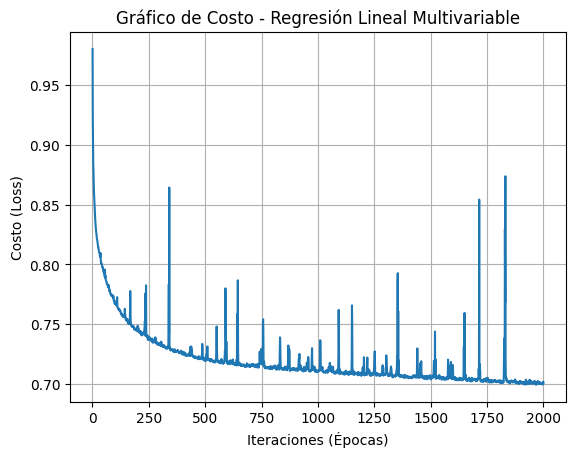

In [5]:
import matplotlib.pyplot as plt

# --- 1.3 Diseño del Modelo (Deep Learning - Multicapa) ---
# Extraemos el número total de características (columnas) de X_train para saber cuántas entradas tendrá la red
D_in = X_train.shape[1]
# Definimos 50 neuronas para la primera capa oculta (este número se elige experimentando para darle capacidad de aprender al modelo)
H1 = 50
# Definimos 1 neurona de salida porque queremos predecir un solo valor numérico continuo (los "shares")
D_out = 1

# Creamos el modelo usando nn.Sequential, que apila las capas en orden consecutivo
model_reg = torch.nn.Sequential(
    # Primera capa lineal (Capa de entrada a Capa Oculta). Aplica la fórmula: y = xA^T + b
    torch.nn.Linear(D_in, H1),
    # Función de activación ReLU (Rectified Linear Unit). Convierte números negativos a 0. Ayuda a aprender relaciones no lineales.
    torch.nn.ReLU(),
    # Segunda capa lineal (Capa Oculta a Capa de Salida). Toma las 50 neuronas y las condensa en 1 salida.
    torch.nn.Linear(H1, D_out)
).to(device) # .to(device) envía toda la red a la memoria de la Tarjeta Gráfica (GPU) o Procesador calculada antes

# --- 1.4 Optimizador y Función de Pérdida ---
# Definimos la función de pérdida (Costo) como Error Cuadrático Medio. Excelente para problemas de regresión porque penaliza errores grandes.
criterion = torch.nn.MSELoss()

# Definimos el optimizador Adam. Su trabajo es actualizar los "pesos" del modelo para minimizar el error.
# lr=0.001 es el ritmo de aprendizaje (qué tan grandes son los pasos que da para aprender).
# weight_decay=1e-4 añade penalización (Regularización L2) para evitar que el modelo memorice los datos en vez de entenderlos (Overfitting).
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

# --- 1.5 Bucle de Entrenamiento (Training Loop) ---
# Número de veces que el modelo verá TODO el conjunto de datos completo
epochs = 2000
# Imprimir el costo en pantalla cada 100 épocas para no saturar la salida
log_each = 100
# Lista vacía para guardar el error en cada época y poder graficarlo después
l = []

# Ponemos explícitamente el modelo en "modo entrenamiento" (activa cálculos de gradientes y dropouts)
model_reg.train()

print("Iniciando Entrenamiento...")
for e in range(1, epochs + 1): # Iniciamos el ciclo para cada época
    _l = [] # Lista temporal para guardar el costo de los batches dentro de una misma época

    # Extraemos pequeños grupos de datos (batches) usando el dataloader
    # x_b: características, y_b: respuestas reales
    for x_b, y_b in dataloader_train_reg:
        # 1. FORWARD PASS: Pasamos las características por la red para obtener predicciones
        y_pred = model_reg(x_b)

        # 2. CALCULAR PÉRDIDA: Comparamos predicciones (y_pred) vs realidad (y_b) usando MSELoss
        loss = criterion(y_pred, y_b)
        _l.append(loss.item()) # .item() extrae el número del tensor de Pytorch y lo guarda en la lista temporal

        # 3. LIMPIAR GRADIENTES: Vaciamos la memoria de los gradientes (derivadas) de la iteración anterior
        optimizer.zero_grad()

        # 4. BACKPROPAGATION: Pytorch calcula la derivada del error respecto a cada peso de la red (hacia atrás)
        loss.backward()

        # 5. ACTUALIZAR PESOS: El optimizador Adam ajusta los pesos de las neuronas en dirección contraria al error
        optimizer.step()

    # Calculamos el promedio del error de todos los batches y lo guardamos como el error histórico de esta época
    l.append(np.mean(_l))

    # Si la época actual es múltiplo de 100 (log_each), mostramos el avance en pantalla
    if not e % log_each:
        print(f"Epoch {e}/{epochs} - Costo (Loss): {np.mean(l):.5f}")

print("Entrenamiento finalizado.")

# --- 1.6 Guardado del Modelo (Checkpoint) ---
# Definimos el nombre y ruta del archivo donde guardaremos los "conocimientos" de la red
PATH = './checkpoint_regresion.pt'
# .state_dict() extrae los pesos aprendidos y torch.save los guarda en disco
torch.save(model_reg.state_dict(), PATH)
print(f"Modelo guardado en: {PATH}")

# --- 1.7 Gráfico de Costo ---
# Graficamos el historial de aprendizaje. Si va bajando como una curvita, el modelo aprendió bien.
plt.plot(range(1, epochs + 1), l)
plt.title('Gráfico de Costo - Regresión Lineal Multivariable')
plt.xlabel('Iteraciones (Épocas)')
plt.ylabel('Costo (Loss)')
plt.grid(True)
plt.show()

In [6]:
# --- 1.8 Evaluación y Validaciones (Prueba de efectividad) ---
# Cambiamos explícitamente a modo ".eval()" (Modo Evaluación).
# Esto le avisa a PyTorch: "Alerta, el estudiante está dando su examen. Apaga el modo de aprendizaje y desactiva Dropouts o cosas aleatorias".
model_reg.eval()

# Según las instrucciones: "realizar por lo menos 100 predicciones que demuestren la efectividad".
# Tomaremos los primeros 100 ejemplos de nuestro conjunto de Test (el 20% que el modelo NO vio durante las 2000 épocas en Entrenamiento).
# Lo convertimos a tensor y enviamos al (device) para que la gráfica responda.
X_prueba = torch.from_numpy(X_test[:100]).float().to(device)

# También extraemos nosotros aparte en paralelo las "100" respuestas correctas para luego poder cruzarlas (como la plantilla de un profesor).
y_prueba_real = y_test[:100]

# with torch.no_grad() -> "SIN GRADIENTES". Como no queremos aprender, no necesitamos que PyTorch guarde las derivadas de error (que ocupan demasiada memoria RAM).
with torch.no_grad():
    # Literalmente evaluamos el tensor "X" (100 datos nuevos) y guardamos la predicción neta que soltó.
    y_prediccion = model_reg(X_prueba)

# Descargamos los tensores mágicos de la GPU hacia el procesador central "CPU", y lo volvemos un array común de NumPy (.numpy()).
y_pred_numpy = y_prediccion.cpu().numpy()

# ----------------- PROCESO INVERSO: DESNORMALIZAR ----------------
# Recordatorio: Arribita le habíamos aplicado la normalización Matemática de Z-Score Y también el logaritmo Natural (log1p).
# Para saber si la respuesta realmente son "3.5 millones de shares" necesitamos invertir esa formula mágica.

# 1. np.expm1 es el Opositivo Exponencial del np.log1p.
# 2. También revertimos la ecuación Zscore (Multiplicando por Dev.Estandar y Sumando la Media).
y_pred_desnormalizada = np.expm1((y_pred_numpy * y_std) + y_mean) # Esta es la predicción devuelta al mundo real de los "Shares"

# Hacemos el MISMO exácto destransformador para la regla original correcta "y_prueba_real" para competir en iguales justas.
y_real_desnormalizada = np.expm1((y_prueba_real * y_std) + y_mean)

# --- IMPRESIÓN DEL MARCADOR VISUAL ----
print(f"--- Realizadas {len(y_pred_numpy)} predicciones exitosamente ---")
print("Mostrando los primeros 20 resultados (Real vs Predicho):")

# Usamos un bucle para graficar estéticamente las primeras 20 pruebas de las 100.
for i in range(20):
    # .0f indica que quite los decimales, un "Share / Compartido" en redes sociales es un entero por default.
    print(f"Ejemplo {i+1} | Valor Real (Shares): {y_real_desnormalizada[i][0]:.0f} | Predicción: {y_pred_desnormalizada[i][0]:.0f}")

# --- PRUEBA GLOBAL EXTENSIVA ---
# Como no basta probar 100 solitos. Pasaremos TODOS los datos que sobraron del testeo.
errores_test = []

# Iteramos de sopetón (Lote por Lote) el DataLoader de prueba "test"
for x_b, y_b in dataloader_test_reg:
    with torch.no_grad():
        y_p = model_reg(x_b)
        # Evaluamos su nivel de error real usando nuestra función madre (MSELoss).
        costo_test = criterion(y_p, y_b)
        errores_test.append(costo_test.item())

# Imprimimos el Error Promedio de Fallar en el mundo real.
# Este numerito tendría que ser lo mas cercano al Último Numerito (loss) de tu entrenamiento, significando que Aprendió bien y no se Memorizó los datos con trampa (Overfitting).
print(f"\nCosto Promedio en Datos de Prueba (Test Loss): {np.mean(errores_test):.5f}")

--- Realizadas 100 predicciones exitosamente ---
Mostrando los primeros 20 resultados (Real vs Predicho):
Ejemplo 1 | Valor Real (Shares): 5000 | Predicción: 2349
Ejemplo 2 | Valor Real (Shares): 701 | Predicción: 1537
Ejemplo 3 | Valor Real (Shares): 5000 | Predicción: 762
Ejemplo 4 | Valor Real (Shares): 812 | Predicción: 642
Ejemplo 5 | Valor Real (Shares): 992 | Predicción: 1196
Ejemplo 6 | Valor Real (Shares): 829 | Predicción: 990
Ejemplo 7 | Valor Real (Shares): 950 | Predicción: 2077
Ejemplo 8 | Valor Real (Shares): 1300 | Predicción: 2710
Ejemplo 9 | Valor Real (Shares): 1300 | Predicción: 1442
Ejemplo 10 | Valor Real (Shares): 1000 | Predicción: 1714
Ejemplo 11 | Valor Real (Shares): 1100 | Predicción: 4538
Ejemplo 12 | Valor Real (Shares): 1000 | Predicción: 1504
Ejemplo 13 | Valor Real (Shares): 805 | Predicción: 1111
Ejemplo 14 | Valor Real (Shares): 786 | Predicción: 1868
Ejemplo 15 | Valor Real (Shares): 776 | Predicción: 1441
Ejemplo 16 | Valor Real (Shares): 945 | Pred

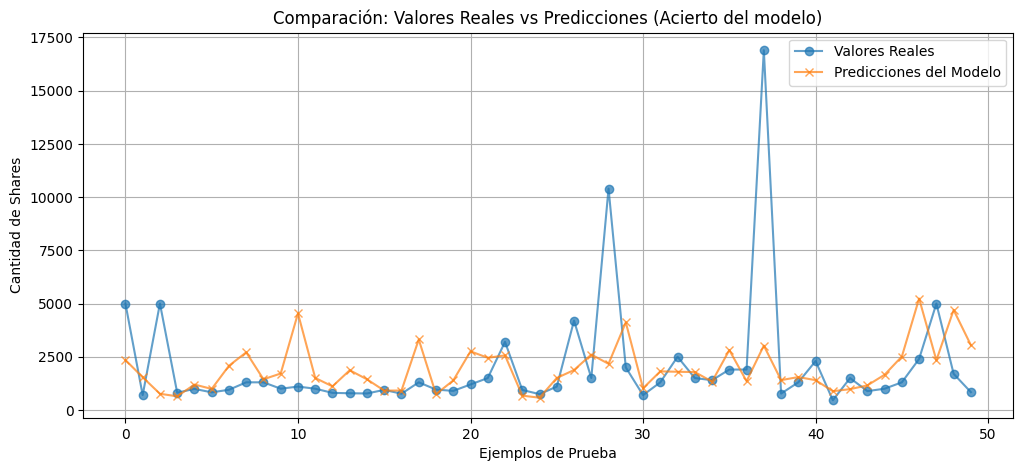

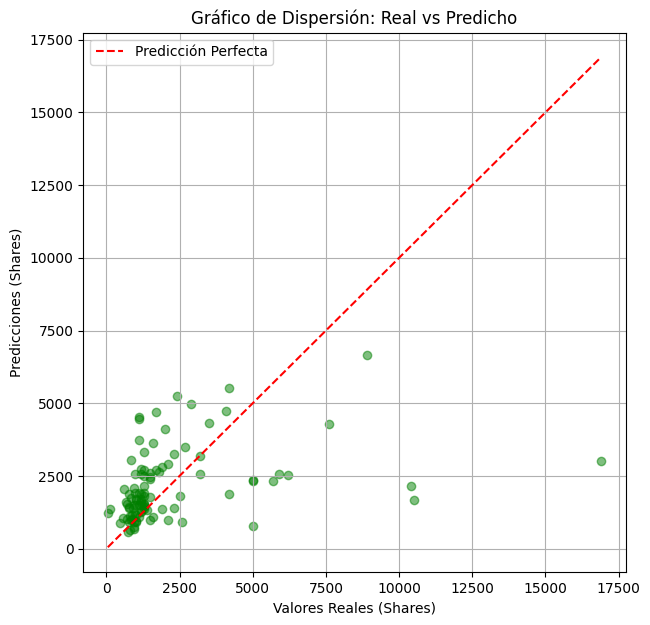

In [7]:
# --- 1.9 Gráficas de "Precisión" (Real vs Predicho) ---
# En modelos de regresión, visualizamos la exactitud comparando qué tan cerca
# están las predicciones de los valores reales.

# 1. Gráfico de Líneas (Primeros 50 ejemplos)
plt.figure(figsize=(12, 5))
plt.plot(y_real_desnormalizada[:50], label='Valores Reales', marker='o', alpha=0.7)
plt.plot(y_pred_desnormalizada[:50], label='Predicciones del Modelo', marker='x', alpha=0.7)
plt.title('Comparación: Valores Reales vs Predicciones (Acierto del modelo)')
plt.xlabel('Ejemplos de Prueba')
plt.ylabel('Cantidad de Shares')
plt.legend()
plt.grid(True)
plt.show()

# 2. Gráfico de Dispersión (Scatter Plot)
# Si el modelo tiene alta precisión, los puntos tenderán a formar una línea diagonal roja.
plt.figure(figsize=(7, 7))
plt.scatter(y_real_desnormalizada, y_pred_desnormalizada, alpha=0.5, color='green')
plt.title('Gráfico de Dispersión: Real vs Predicho')
plt.xlabel('Valores Reales (Shares)')
plt.ylabel('Predicciones (Shares)')

# Trazamos la línea ideal de predicción perfecta (x = y)
min_val = min(min(y_real_desnormalizada), min(y_pred_desnormalizada))
max_val = max(max(y_real_desnormalizada), max(y_pred_desnormalizada))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Predicción Perfecta')
plt.legend()
plt.grid(True)
plt.show()